In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score, roc_curve
from sklearn.preprocessing import LabelEncoder
from imblearn.combine import SMOTEENN
from sklearn.model_selection import GridSearchCV

df = pd.read_csv('Churn_Modelling.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
print(df['Exited'].value_counts())

(10000, 14)
RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64
Exited
0    7963
1    2037
Name: count, dtype: int64


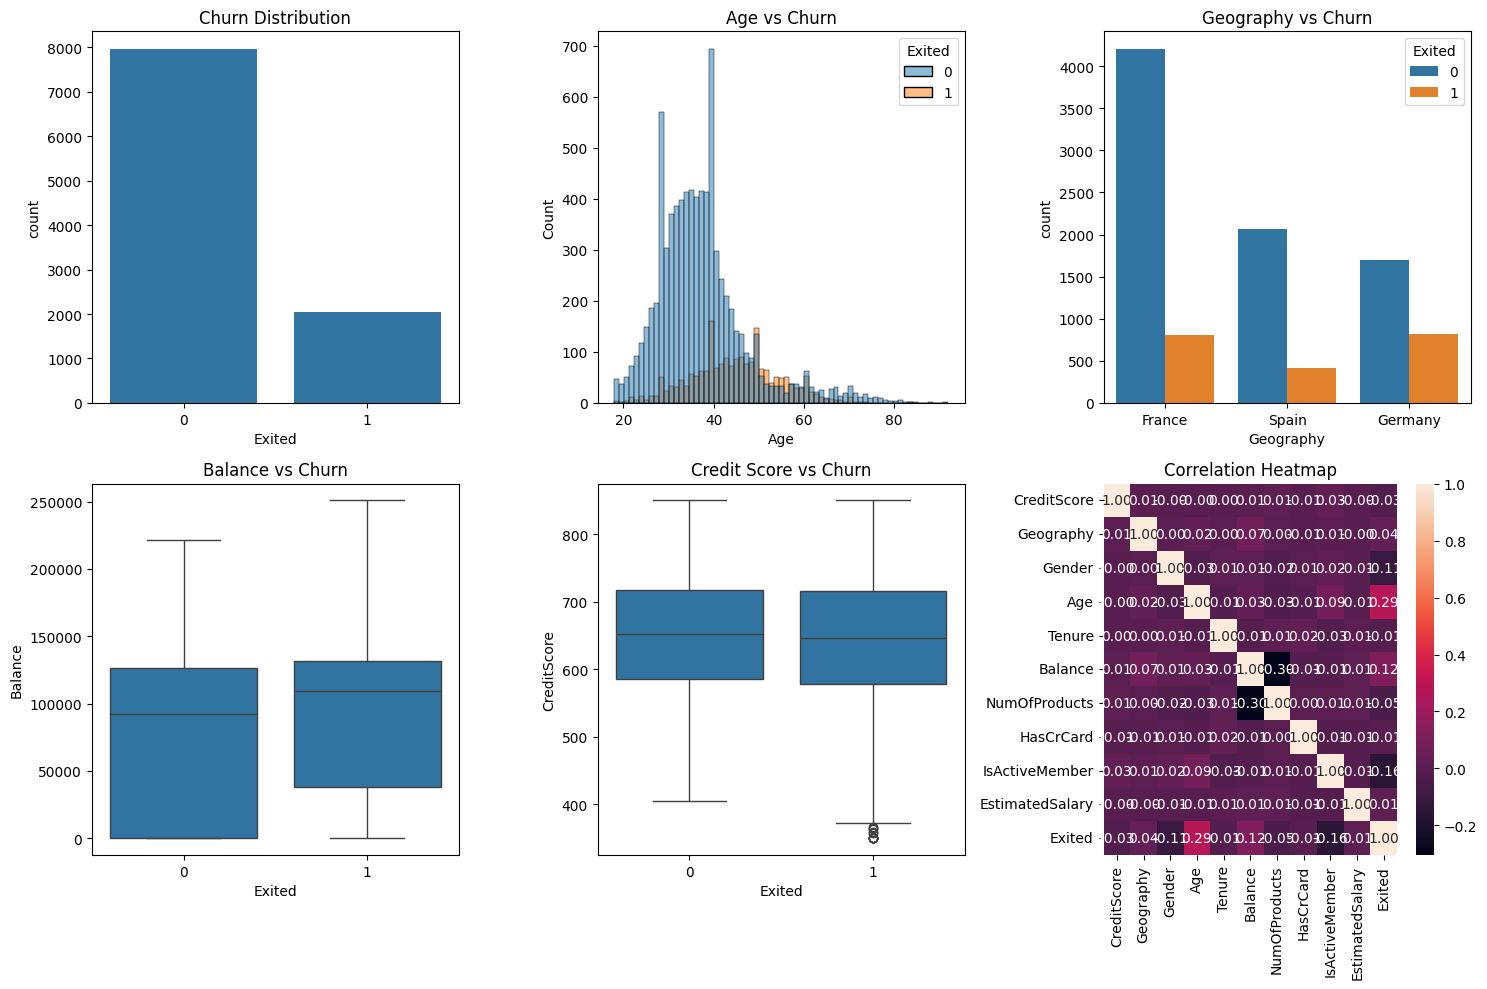

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Churn distribution
sns.countplot(x='Exited', data=df, ax=axes[0,0])
axes[0,0].set_title('Churn Distribution')

# Age distribution
sns.histplot(data=df, x='Age', hue='Exited', ax=axes[0,1])
axes[0,1].set_title('Age vs Churn')

# Geography
sns.countplot(x='Geography', hue='Exited', data=df, ax=axes[0,2])
axes[0,2].set_title('Geography vs Churn')

# Balance
sns.boxplot(x='Exited', y='Balance', data=df, ax=axes[1,0])
axes[1,0].set_title('Balance vs Churn')

# Credit Score
sns.boxplot(x='Exited', y='CreditScore', data=df, ax=axes[1,1])
axes[1,1].set_title('Credit Score vs Churn')

# Correlation heatmap
numeric_df = df.drop(['RowNumber','CustomerId','Surname'], axis=1)
numeric_df['Gender'] = LabelEncoder().fit_transform(numeric_df['Gender'])
numeric_df['Geography'] = LabelEncoder().fit_transform(numeric_df['Geography'])
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', ax=axes[1,2])
axes[1,2].set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()

In [5]:

df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)


le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
df['Geography'] = le.fit_transform(df['Geography'])


X = df.drop('Exited', axis=1)
y = df['Exited']


smote_enn = SMOTEENN(random_state=42)
X_resampled, y_resampled = smote_enn.fit_resample(X, y)

print("Before SMOTEENN:", y.value_counts())
print("After SMOTEENN:", pd.Series(y_resampled).value_counts())


X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)
print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Before SMOTEENN: Exited
0    7963
1    2037
Name: count, dtype: int64
After SMOTEENN: Exited
1    3703
0    2896
Name: count, dtype: int64
Training size: (5279, 10)
Testing size: (1320, 10)


In [6]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)

print("=== Random Forest ===")
print(classification_report(y_test, rf_pred))
print("F1 Score:", f1_score(y_test, rf_pred))

print("=== Gradient Boosting ===")
print(classification_report(y_test, gb_pred))
print("F1 Score:", f1_score(y_test, gb_pred))

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.87      0.84      0.86       577
           1       0.88      0.90      0.89       743

    accuracy                           0.88      1320
   macro avg       0.88      0.87      0.87      1320
weighted avg       0.88      0.88      0.88      1320

F1 Score: 0.8922872340425532
=== Gradient Boosting ===
              precision    recall  f1-score   support

           0       0.86      0.82      0.84       577
           1       0.87      0.90      0.88       743

    accuracy                           0.87      1320
   macro avg       0.87      0.86      0.86      1320
weighted avg       0.87      0.87      0.87      1320

F1 Score: 0.8831683168316832


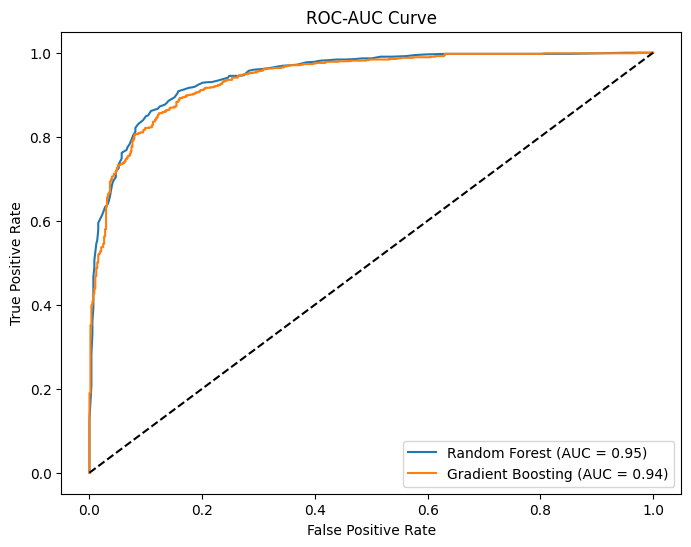

Random Forest AUC: 0.9458
Gradient Boosting AUC: 0.9399


In [7]:
rf_proba = rf.predict_proba(X_test)[:,1]
gb_proba = gb.predict_proba(X_test)[:,1]

rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_proba)
gb_fpr, gb_tpr, _ = roc_curve(y_test, gb_proba)

rf_auc = roc_auc_score(y_test, rf_proba)
gb_auc = roc_auc_score(y_test, gb_proba)

plt.figure(figsize=(8,6))
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_auc:.2f})')
plt.plot(gb_fpr, gb_tpr, label=f'Gradient Boosting (AUC = {gb_auc:.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve')
plt.legend()
plt.show()

print(f"Random Forest AUC: {rf_auc:.4f}")
print(f"Gradient Boosting AUC: {gb_auc:.4f}")

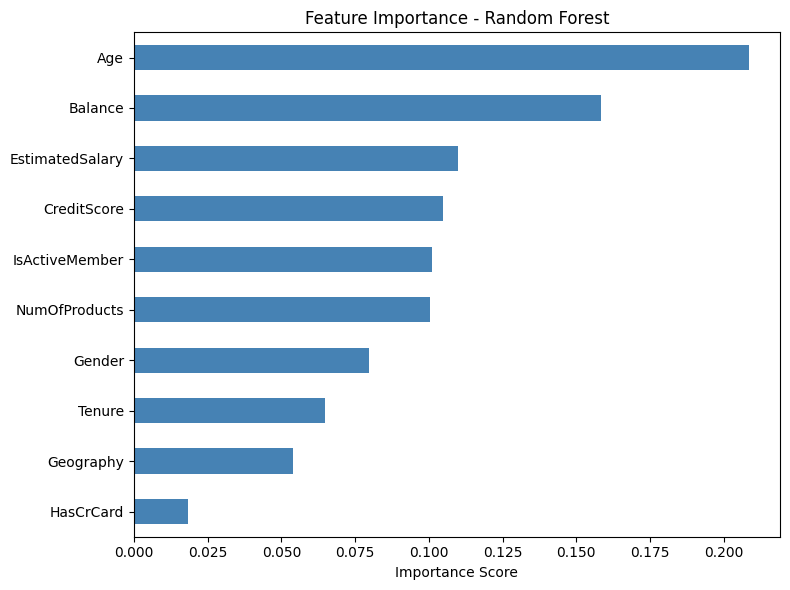

In [8]:
feat_importance = pd.Series(rf.feature_importances_, index=X.columns)
feat_importance.sort_values().plot(kind='barh', figsize=(8,6), color='steelblue')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

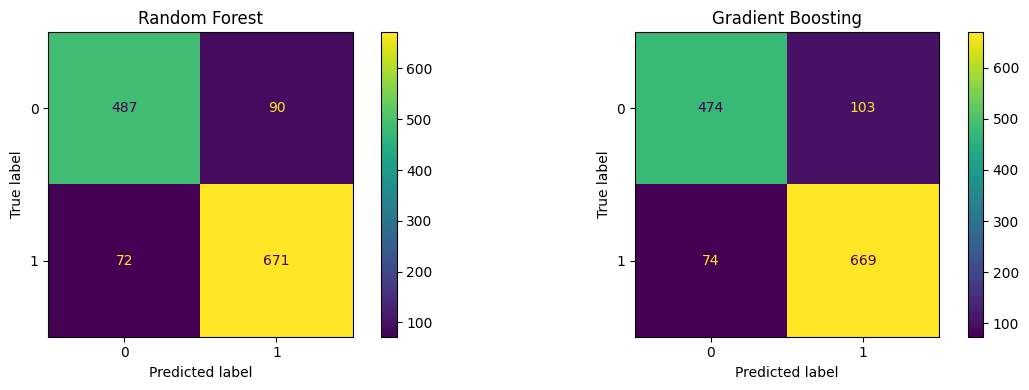

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(y_test, rf_pred, ax=axes[0])
axes[0].set_title('Random Forest')
ConfusionMatrixDisplay.from_predictions(y_test, gb_pred, ax=axes[1])
axes[1].set_title('Gradient Boosting')
plt.tight_layout()
plt.show()